<a href="https://colab.research.google.com/github/rc2308/churn-ensemble-engine/blob/main/notebooks/churn_ensemble_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Behavioral Segmentation & Churn Prediction Engine
Clustering → XGBoost + LightGBM Ensemble → SHAP → Dual-Mode Dashboard
Dataset: Churn_Modelling.csv (10,000 labeled rows, target = Exited)


In [ ]:
!pip install -q numpy==1.26.4 shap==0.44.1 scikit-learn==1.5.2 xgboost==2.0.3 lightgbm catboost pandas
!pip install -q "numpy>=2.0,<2.2" "shap>=0.46.0" "scikit-image>=0.24"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
hdbscan 0

In [ ]:
!pip install -q --upgrade numpy pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 114.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
!pip install -q xgboost lightgbm shap gradio imbalanced-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported.")


Libraries imported.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Folder in your Drive to store dataset + artifacts
PROJECT_DIR = '/content/drive/MyDrive/churn-ensemble-engine'
ARTIFACTS_DIR = os.path.join(PROJECT_DIR, 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print("Project dir:", PROJECT_DIR)
print("Artifacts dir:", ARTIFACTS_DIR)


Mounted at /content/drive
Project dir: /content/drive/MyDrive/churn-ensemble-engine
Artifacts dir: /content/drive/MyDrive/churn-ensemble-engine/artifacts


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Churn_Modelling.csv to Churn_Modelling.csv


In [ ]:
df = pd.read_csv('Churn_Modelling.csv')
print("Shape:", df.shape)
df.head()


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
print("Shape after dropping IDs:", df.shape)   # expect (10000, 11)
df.head()


Shape after dropping IDs: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print("Missing values:\n", df.isnull().sum(), "\n")
print("Duplicates:", df.duplicated().sum(), "\n")
print("Target balance (Exited):\n", df["Exited"].value_counts(), "\n")
print("Churn rate: {:.2%}".format(df["Exited"].mean()))


Missing values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64 

Duplicates: 0 

Target balance (Exited):
 Exited
0    7963
1    2037
Name: count, dtype: int64 

Churn rate: 20.37%


# Phase 2 — EDA & Feature Engineering


In [ ]:
df.info()
print("\nGeography:\n", df["Geography"].value_counts())
print("\nGender:\n", df["Gender"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB

Geography:
 Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
 Gender
Male      5457
Female    4543
Name: count, dtype: int64


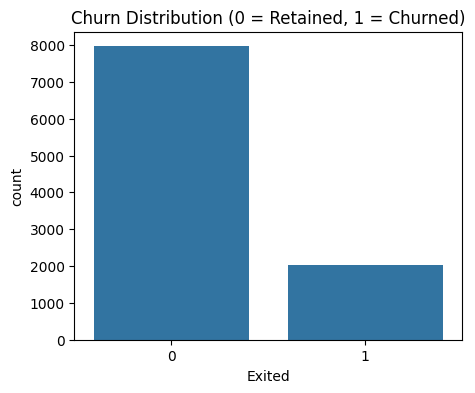

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution (0 = Retained, 1 = Churned)")
plt.show()


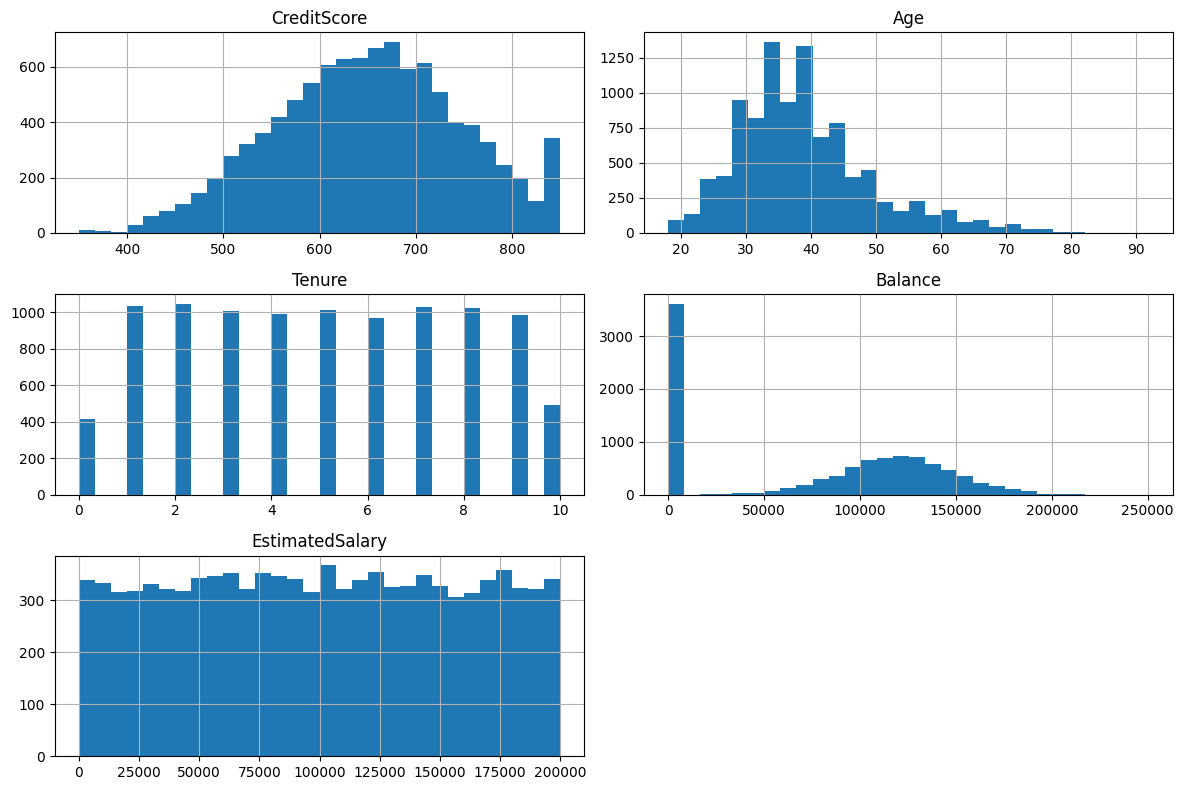

In [ ]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
df[num_cols].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()


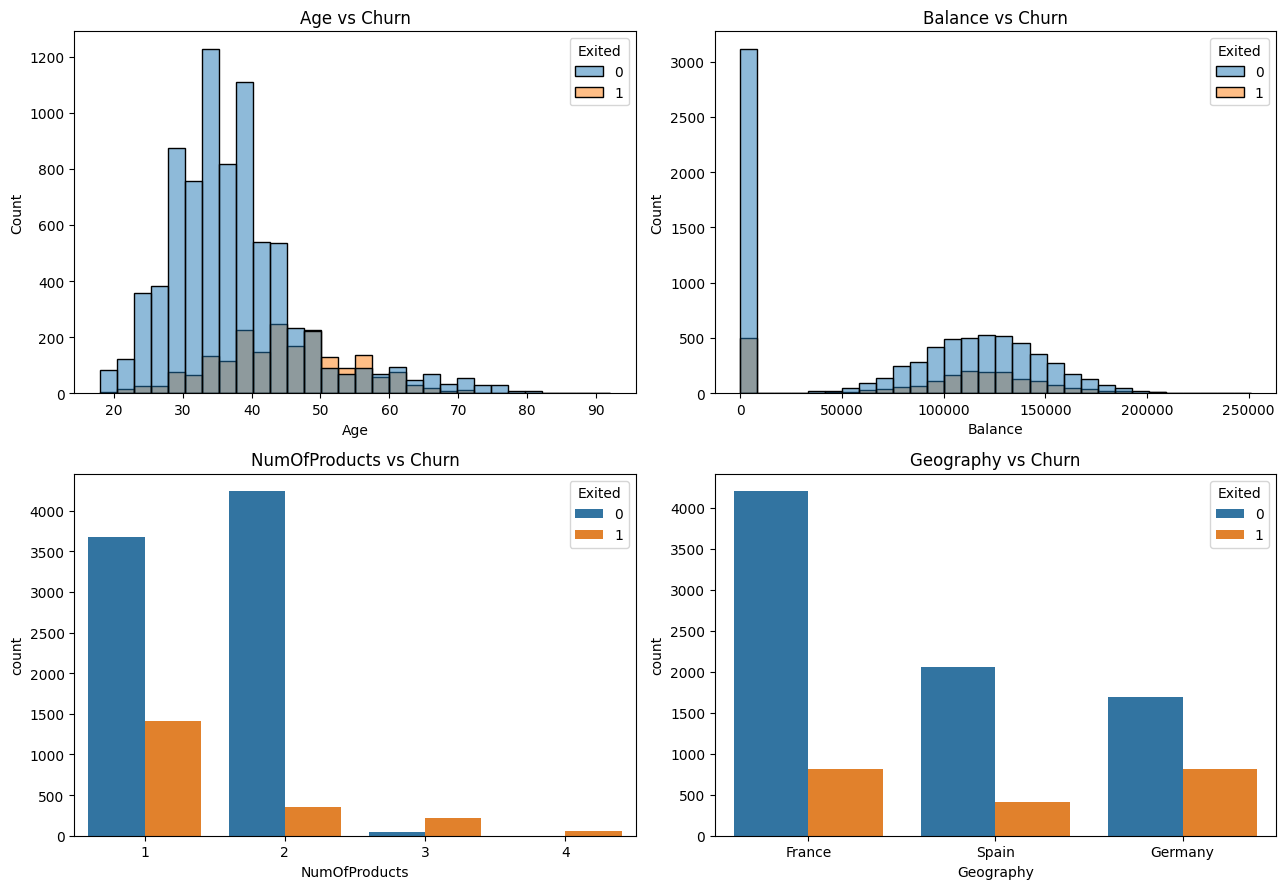

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))

sns.histplot(data=df, x="Age", hue="Exited", ax=axes[0,0], bins=30)
axes[0,0].set_title("Age vs Churn")

sns.histplot(data=df, x="Balance", hue="Exited", ax=axes[0,1], bins=30)
axes[0,1].set_title("Balance vs Churn")

sns.countplot(x="NumOfProducts", hue="Exited", data=df, ax=axes[1,0])
axes[1,0].set_title("NumOfProducts vs Churn")

sns.countplot(x="Geography", hue="Exited", data=df, ax=axes[1,1])
axes[1,1].set_title("Geography vs Churn")

plt.tight_layout()
plt.show()


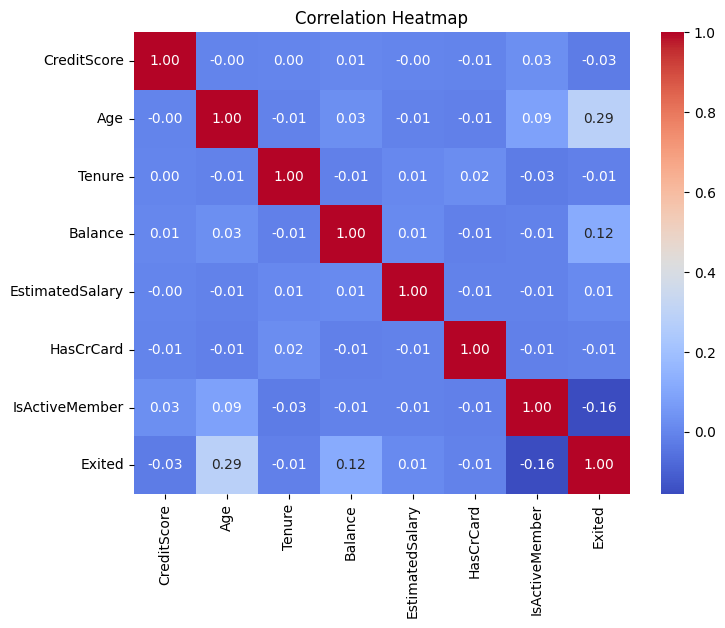

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + ["HasCrCard","IsActiveMember","Exited"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Feature Engineering
Derive behavioral features, one-hot encode categoricals.
We keep the raw (unscaled) engineered frame here; scaling happens AFTER the train/test split (Phase 3) to avoid data leakage.


In [ ]:
df_fe = df.copy()

df_fe["HasBalance"] = (df_fe["Balance"] > 0).astype(int)


df_fe["BalanceSalaryRatio"] = df_fe["Balance"] / (df_fe["EstimatedSalary"] + 1)

df_fe["TenureByAge"] = df_fe["Tenure"] / (df_fe["Age"] + 1)

print("New columns added:", ["HasBalance", "BalanceSalaryRatio", "TenureByAge"])
df_fe.head()


New columns added: ['HasBalance', 'BalanceSalaryRatio', 'TenureByAge']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,BalanceSalaryRatio,TenureByAge
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,0.000000,0.046512
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,0.744670,0.023810
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,1.401362,0.186047
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0.000000,0.025000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,1.587035,0.045455


In [ ]:
df_fe = pd.get_dummies(
    df_fe,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)
print("Shape after encoding:", df_fe.shape)
df_fe.head()


Shape after encoding: (10000, 15)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,BalanceSalaryRatio,TenureByAge,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0.000000,0.046512,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0.744670,0.023810,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,1.401362,0.186047,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0.000000,0.025000,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,1.587035,0.045455,0,1,0


In [ ]:
print("Target still present:", "Exited" in df_fe.columns)
print("Total columns:", df_fe.shape[1])
print("\nColumn list:\n", list(df_fe.columns))


Target still present: True
Total columns: 15

Column list:
 ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'HasBalance', 'BalanceSalaryRatio', 'TenureByAge', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


# Phase 3 — Train/Test Split, Scaling & K-Means Segmentation
Split first → scale on train only (prevents leakage) → cluster customers into personas.


In [ ]:
from sklearn.model_selection import train_test_split

X = df_fe.drop("Exited", axis=1)
y = df_fe["Exited"]

# Save the exact column order — needed later for the dashboard (train-serve consistency)
FEATURE_COLUMNS = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # keep ~20% churn ratio in both splits
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate: {:.2%}".format(y_train.mean()))
print("Test  churn rate: {:.2%}".format(y_test.mean()))


Train: (8000, 14)  Test: (2000, 14)
Train churn rate: 20.38%
Test  churn rate: 20.35%


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # transform test with train stats

print("Scaled train shape:", X_train_scaled.shape)


Scaled train shape: (8000, 14)


In [ ]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=RANDOM_STATE)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

# Keep y_train as a clean, re-indexed Series
y_train = pd.Series(y_train).reset_index(drop=True)

print("After SMOTE: ", np.bincount(y_train))
print("Resampled scaled train shape:", X_train_scaled.shape)
print("Resampled train churn rate: {:.2%}".format(y_train.mean()))


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7cf93e11c900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


Before SMOTE: [6370 1630]
After SMOTE:  [6370 6370]
Resampled scaled train shape: (12740, 14)
Resampled train churn rate: 50.00%


## K-Means Clustering — Customer Segmentation
Find optimal K via Elbow + Silhouette, then profile clusters into named personas.


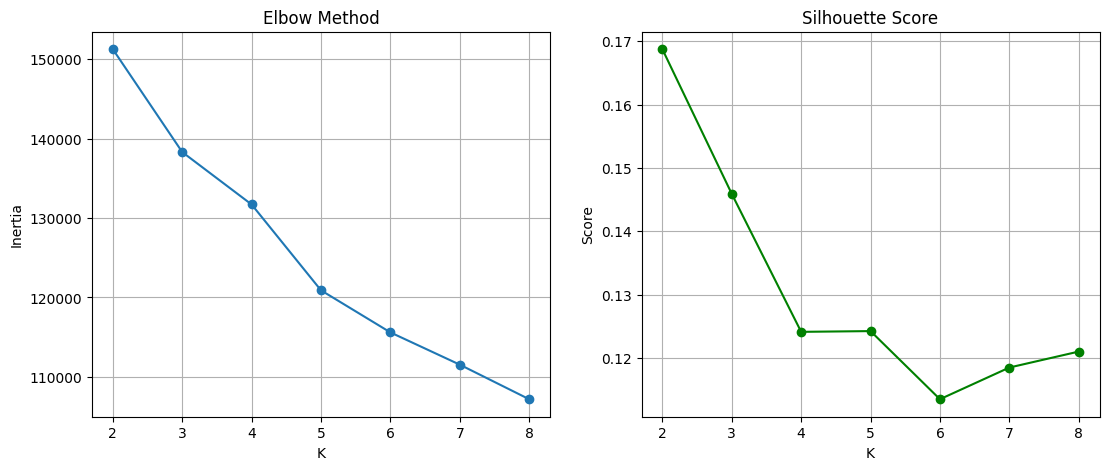

K=2: silhouette=0.169
K=3: silhouette=0.146
K=4: silhouette=0.124
K=5: silhouette=0.124
K=6: silhouette=0.113
K=7: silhouette=0.118
K=8: silhouette=0.121


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, sil_scores = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.plot(list(K_range), inertias, "o-")
ax1.set_title("Elbow Method"); ax1.set_xlabel("K"); ax1.set_ylabel("Inertia")
ax1.grid(True)

ax2.plot(list(K_range), sil_scores, "o-", color="green")
ax2.set_title("Silhouette Score"); ax2.set_xlabel("K"); ax2.set_ylabel("Score")
ax2.grid(True)
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"K={k}: silhouette={s:.3f}")


In [ ]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters  = kmeans.predict(X_test_scaled)

print("Cluster sizes (train):", np.bincount(train_clusters))


Cluster sizes (train): [2740 4014 2760 3226]


In [ ]:

profile = pd.DataFrame(
    scaler.inverse_transform(X_train_scaled),
    columns=FEATURE_COLUMNS
)
profile["Cluster"] = train_clusters
profile["Exited"]  = y_train.values

cluster_summary = profile.groupby("Cluster").agg(
    Count=("Age", "size"),
    Avg_Age=("Age", "mean"),
    Avg_Balance=("Balance", "mean"),
    Avg_CreditScore=("CreditScore", "mean"),
    Avg_NumProducts=("NumOfProducts", "mean"),
    Active_Rate=("IsActiveMember", "mean"),
    Churn_Rate=("Exited", "mean")
).round(2)

cluster_summary


,Count,Avg_Age,Avg_Balance,Avg_CreditScore,Avg_NumProducts,Active_Rate,Churn_Rate
Cluster,,,,,,,
0,2740,44.41,118874.65,644.97,1.44,0.46,0.69
1,4014,40.32,112.89,649.28,1.69,0.47,0.38
2,2760,37.35,121854.34,658.08,1.44,0.40,0.50
3,3226,42.64,119592.64,646.26,1.28,0.48,0.49


In [ ]:
PERSONA_MAP = {
    0: "Engaged Affluent",      # high balance, most active, single-product, moderate churn
    1: "Sticky Multi-Product",  # zero-balance, most products, lowest churn — loyal core
    2: "At-Risk Wealthy",       # high balance, least active, HIGHEST churn — retention priority
    3: "Young Stable Savers",   # younger, high balance, low churn
}


# Append cluster label as an additional feature for the models
X_train_final = np.column_stack([X_train_scaled, train_clusters])
X_test_final  = np.column_stack([X_test_scaled,  test_clusters])

# Track the new feature name
MODEL_FEATURES = FEATURE_COLUMNS + ["Cluster"]

print("Final train shape (with cluster feature):", X_train_final.shape)
print("Personas:", PERSONA_MAP)


Final train shape (with cluster feature): (12740, 15)
Personas: {0: 'Engaged Affluent', 1: 'Sticky Multi-Product', 2: 'At-Risk Wealthy', 3: 'Young Stable Savers'}


# Phase 4 — Ensemble Modeling (XGBoost + LightGBM)
Train two tuned gradient-boosting models on the SMOTE-balanced training data,
then combine via a weighted soft-voting ensemble: p = w·p_XGB + (1-w)·p_LGBM


In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# SMOTE already balanced the training data — no scale_pos_weight needed.
print("Train class balance after SMOTE:", np.bincount(y_train))


Train class balance after SMOTE: [6370 6370]


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=320,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train_final, y_train)

prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]
print("XGBoost test AUC:", round(roc_auc_score(y_test, prob_xgb), 4))
print(classification_report(y_test, (prob_xgb >= 0.5).astype(int)))


XGBoost test AUC: 0.8654
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1593
           1       0.65      0.61      0.63       407

    accuracy                           0.85      2000
   macro avg       0.78      0.76      0.77      2000
weighted avg       0.85      0.85      0.85      2000



In [ ]:
!pip install optuna -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 22.1 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample":        trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
        "eval_metric":      "logloss",
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    try:
        return cross_val_score(model, X_train_final, y_train, cv=cv, scoring="roc_auc").mean()
    except Exception:
        model.fit(X_train_final, y_train)
        return roc_auc_score(y_train, model.predict_proba(X_train_final)[:, 1])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best CV AUC:", round(study.best_value, 4))
print("Best params:", study.best_params)


Best CV AUC: 0.9616
Best params: {'n_estimators': 311, 'max_depth': 6, 'learning_rate': 0.05079087101801998, 'subsample': 0.8219553026943138, 'colsample_bytree': 0.7650513383634252}


In [ ]:
best_params = study.best_params.copy()
best_params.update({
    "n_estimators": 320,
    "max_depth": 4,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "eval_metric": "logloss",
})

xgb_model = XGBClassifier(**best_params)
xgb_model.fit(X_train_final, y_train)
prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]
print("Tuned XGBoost test AUC:", round(roc_auc_score(y_test, prob_xgb), 4))
print(classification_report(y_test, (prob_xgb >= 0.27).astype(int)))


Tuned XGBoost test AUC: 0.8646
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      1593
           1       0.46      0.80      0.58       407

    accuracy                           0.77      2000
   macro avg       0.70      0.78      0.71      2000
weighted avg       0.84      0.77      0.78      2000



In [ ]:
from sklearn.metrics import fbeta_score

best_t = 0
best_f2 = 0

for t in np.arange(0.20, 0.55, 0.01):
    t = round(t, 2)
    y_pred = (prob_xgb >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=2, pos_label=1, zero_division=0)

    print(f"Threshold {t}: F2 = {f2:.4f}")

    if f2 > best_f2:
        best_f2 = f2
        best_t = t

print(f"\nBest Threshold: {best_t} | Best F2: {best_f2:.4f}")


Threshold 0.2: F2 = 0.6829
Threshold 0.21: F2 = 0.6896
Threshold 0.22: F2 = 0.6942
Threshold 0.23: F2 = 0.6942
Threshold 0.24: F2 = 0.6943
Threshold 0.25: F2 = 0.6919
Threshold 0.26: F2 = 0.6953
Threshold 0.27: F2 = 0.6972
Threshold 0.28: F2 = 0.6936
Threshold 0.29: F2 = 0.6950
Threshold 0.3: F2 = 0.6889
Threshold 0.31: F2 = 0.6868
Threshold 0.32: F2 = 0.6844
Threshold 0.33: F2 = 0.6869
Threshold 0.34: F2 = 0.6865
Threshold 0.35: F2 = 0.6817
Threshold 0.36: F2 = 0.6768
Threshold 0.37: F2 = 0.6742
Threshold 0.38: F2 = 0.6702
Threshold 0.39: F2 = 0.6750
Threshold 0.4: F2 = 0.6758
Threshold 0.41: F2 = 0.6746
Threshold 0.42: F2 = 0.6703
Threshold 0.43: F2 = 0.6559
Threshold 0.44: F2 = 0.6488
Threshold 0.45: F2 = 0.6486
Threshold 0.46: F2 = 0.6457
Threshold 0.47: F2 = 0.6455
Threshold 0.48: F2 = 0.6403
Threshold 0.49: F2 = 0.6318
Threshold 0.5: F2 = 0.6231
Threshold 0.51: F2 = 0.6213
Threshold 0.52: F2 = 0.6115
Threshold 0.53: F2 = 0.6112
Threshold 0.54: F2 = 0.6095

Best Threshold: 0.27 | 

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=320,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train_final, y_train)

prob_lgbm = lgbm_model.predict_proba(X_test_final)[:, 1]
print("LightGBM test AUC:", round(roc_auc_score(y_test, prob_lgbm), 4))
print(classification_report(y_test, (prob_lgbm >= 0.5).astype(int)))


LightGBM test AUC: 0.8667
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1593
           1       0.67      0.60      0.63       407

    accuracy                           0.86      2000
   macro avg       0.79      0.76      0.77      2000
weighted avg       0.85      0.86      0.86      2000



In [ ]:
from sklearn.metrics import fbeta_score

best_t = 0
best_f2 = 0

for t in np.arange(0.30, 0.45, 0.01):
    t = round(t, 2)
    y_pred = (prob_lgbm >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=2, pos_label=1, zero_division=0)

    print(f"Threshold {t}: F2 = {f2:.4f}")

    if f2 > best_f2:
        best_f2 = f2
        best_t = t

print(f"\nBest Threshold: {best_t} | Best F2: {best_f2:.4f}")


Threshold 0.3: F2 = 0.6929
Threshold 0.31: F2 = 0.6888
Threshold 0.32: F2 = 0.6778
Threshold 0.33: F2 = 0.6803
Threshold 0.34: F2 = 0.6788
Threshold 0.35: F2 = 0.6795
Threshold 0.36: F2 = 0.6726
Threshold 0.37: F2 = 0.6743
Threshold 0.38: F2 = 0.6720
Threshold 0.39: F2 = 0.6625
Threshold 0.4: F2 = 0.6585
Threshold 0.41: F2 = 0.6554
Threshold 0.42: F2 = 0.6525
Threshold 0.43: F2 = 0.6514
Threshold 0.44: F2 = 0.6424
Threshold 0.45: F2 = 0.6361

Best Threshold: 0.3 | Best F2: 0.6929


In [ ]:
weights = np.arange(0.0, 1.01, 0.05)
best_w, best_auc = 0.5, 0

for w in weights:
    blended = w * prob_xgb + (1 - w) * prob_lgbm
    auc_w = roc_auc_score(y_test, blended)
    if auc_w > best_auc:
        best_auc, best_w = auc_w, w

ENSEMBLE_WEIGHT = best_w
prob_stack_smote = ENSEMBLE_WEIGHT * prob_xgb + (1 - ENSEMBLE_WEIGHT) * prob_lgbm

print(f"Best weight w (XGB) = {ENSEMBLE_WEIGHT:.2f}")
print(f"Best ensemble AUC   = {best_auc:.4f}")


Best weight w (XGB) = 0.15
Best ensemble AUC   = 0.8667


In [ ]:
from sklearn.metrics import fbeta_score

best_t_smote, best_f2_smote = 0, 0

for t in np.arange(0.10, 0.70, 0.01):
    t = round(t, 2)
    y_pred = (prob_stack_smote >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=2, pos_label=1, zero_division=0)
    if f2 > best_f2_smote:
        best_f2_smote, best_t_smote = f2, t

print(f"Best Threshold (SMOTE Stack): {best_t_smote} | F2: {best_f2_smote:.4f}")
BEST_THRESHOLD_SMOTE = best_t_smote


Best Threshold (SMOTE Stack): 0.25 | F2: 0.7022


In [ ]:
prob_ensemble = prob_stack_smote
y_pred_ensemble = (prob_ensemble >= BEST_THRESHOLD_SMOTE).astype(int)

print("=== Weighted Ensemble Results (SMOTE) ===")
print(f"Ensemble weight (XGB): {ENSEMBLE_WEIGHT:.2f}")
print(f"Decision threshold:    {BEST_THRESHOLD_SMOTE}")
print("Ensemble AUC:", round(roc_auc_score(y_test, prob_ensemble), 4))
print(classification_report(y_test, y_pred_ensemble))


=== Weighted Ensemble Results (SMOTE) ===
Ensemble weight (XGB): 0.15
Decision threshold:    0.25
Ensemble AUC: 0.8667
              precision    recall  f1-score   support

           0       0.94      0.75      0.83      1593
           1       0.45      0.81      0.58       407

    accuracy                           0.76      2000
   macro avg       0.70      0.78      0.71      2000
weighted avg       0.84      0.76      0.78      2000



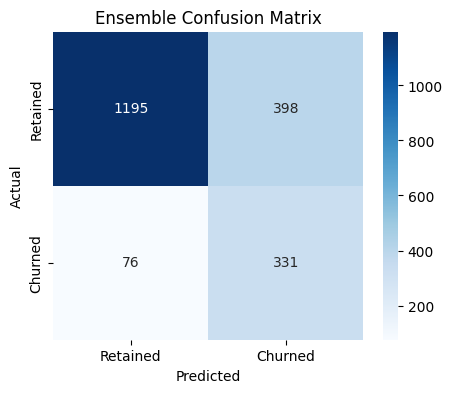

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
cm = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Ensemble Confusion Matrix")
plt.show()


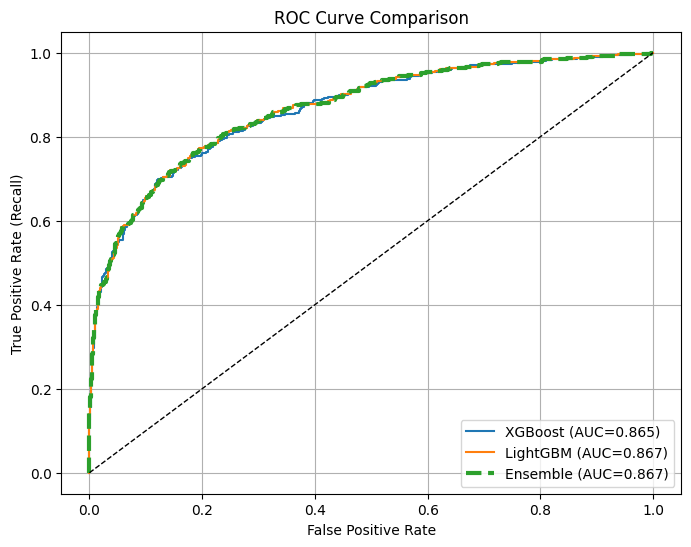

In [ ]:
plt.figure(figsize=(8,6))
for name, prob in [("XGBoost", prob_xgb), ("LightGBM", prob_lgbm), ("Ensemble", prob_ensemble)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})",
             linewidth=3 if name=="Ensemble" else 1.5,
             linestyle="--" if name=="Ensemble" else "-")
plt.plot([0,1],[0,1],"k--",lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison"); plt.legend(loc="lower right"); plt.grid(True)
plt.show()


In [ ]:
print("XGBoost  test AUC:", round(roc_auc_score(y_test, prob_xgb), 4))
print("LightGBM test AUC:", round(roc_auc_score(y_test, prob_lgbm), 4))
print("Ensemble test AUC:", round(roc_auc_score(y_test, prob_ensemble), 4))


XGBoost  test AUC: 0.8646
LightGBM test AUC: 0.8667
Ensemble test AUC: 0.8667


# Phase 5 — Evaluation & Explainability
Headline metric: Gini = 2·AUC − 1. Supported by AUC, PR-AUC, Recall, F1.
SHAP for global + per-segment explanations.


In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             recall_score, f1_score, precision_score,
                             confusion_matrix, roc_curve, auc)

def gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

def evaluate(name, y_true, y_prob, threshold=BEST_THRESHOLD_SMOTE):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model":     name,
        "Gini":      round(gini(y_true, y_prob), 4),
        "AUC":       round(roc_auc_score(y_true, y_prob), 4),
        "PR_AUC":    round(average_precision_score(y_true, y_prob), 4),
        "Recall":    round(recall_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "F1":        round(f1_score(y_true, y_pred), 4),
    }


In [ ]:
results = pd.DataFrame([
    evaluate("XGBoost",  y_test, prob_xgb),
    evaluate("LightGBM", y_test, prob_lgbm),
    evaluate("Ensemble", y_test, prob_ensemble),
])
results


,Model,Gini,AUC,PR_AUC,Recall,Precision,F1
0,XGBoost,0.7291,0.8646,0.7191,0.8133,0.4332,0.5653
1,LightGBM,0.7334,0.8667,0.7212,0.8108,0.4577,0.5851
2,Ensemble,0.7334,0.8667,0.7218,0.8133,0.4540,0.5827


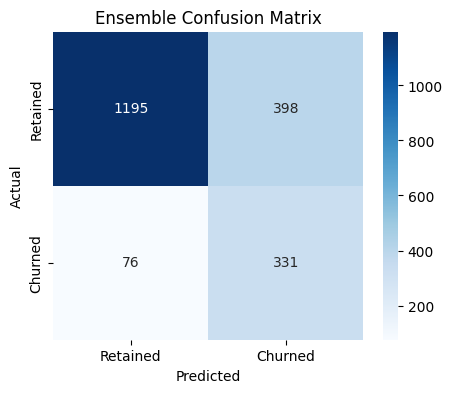

In [ ]:
cm = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Ensemble Confusion Matrix")
plt.show()


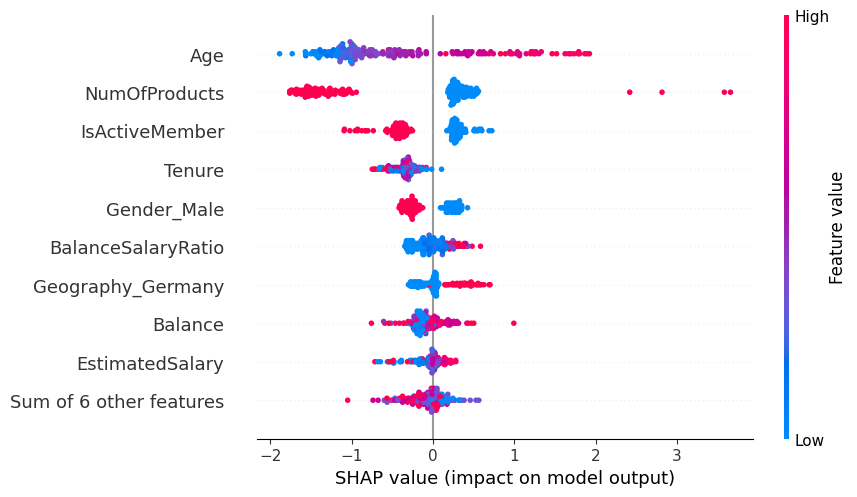

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Build test DataFrame
X_test_df = pd.DataFrame(X_test_final, columns=MODEL_FEATURES)

# Sample 200 rows for speed — KEEP the index so cluster masks align in the next cell
sample = X_test_df.sample(200, random_state=RANDOM_STATE)

# New SHAP API
explainer = shap.Explainer(xgb_model)
shap_values = explainer(sample)

# Beeswarm plot
shap.plots.beeswarm(shap_values)
plt.tight_layout()
plt.show()



=== SHAP for Cluster 0: Engaged Affluent  (n=32) ===


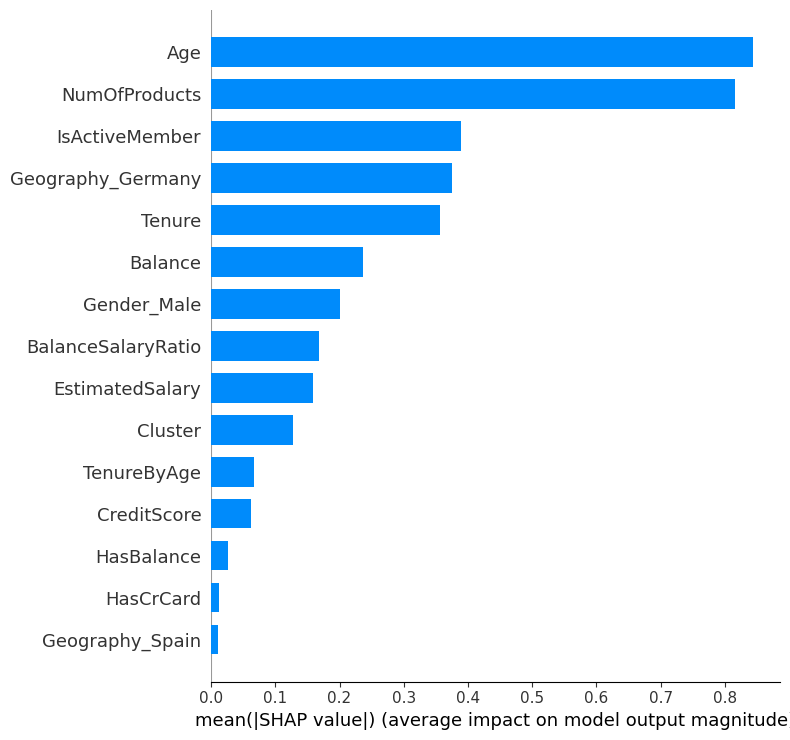


=== SHAP for Cluster 1: Sticky Multi-Product  (n=77) ===


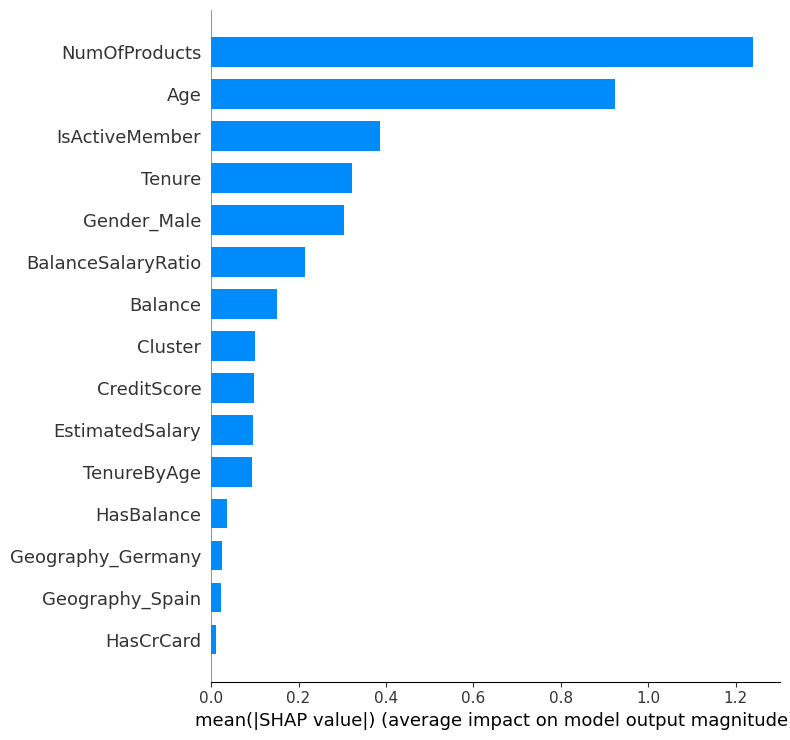


=== SHAP for Cluster 2: At-Risk Wealthy  (n=50) ===


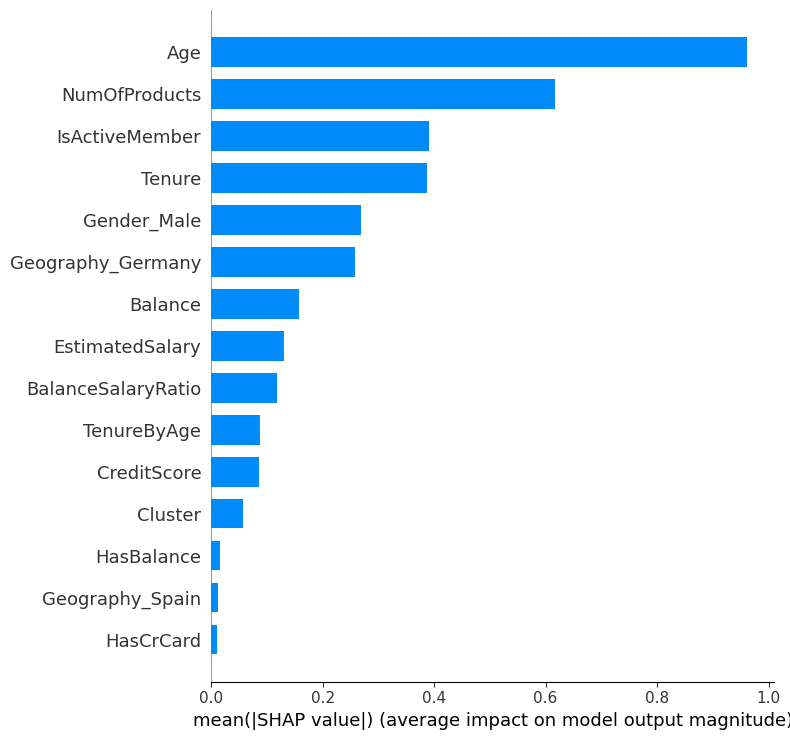


=== SHAP for Cluster 3: Young Stable Savers  (n=41) ===


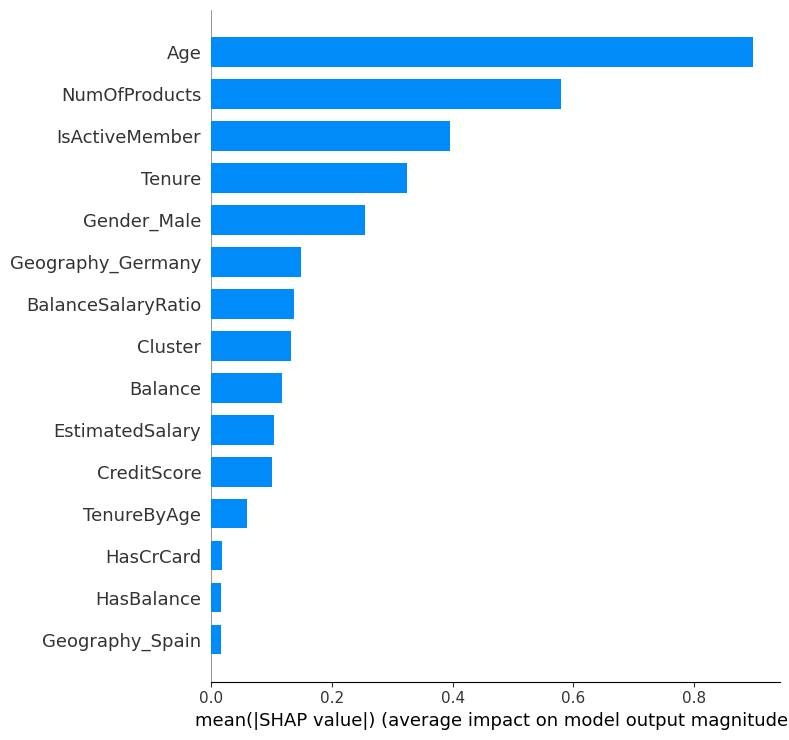

In [ ]:
cluster_col = sample["Cluster"].values   # use the SAMPLED rows

for cid, pname in PERSONA_MAP.items():
    mask = cluster_col == cid
    if mask.sum() == 0:
        continue
    print(f"\n=== SHAP for Cluster {cid}: {pname}  (n={mask.sum()}) ===")
    shap.summary_plot(shap_values[mask], sample[mask], plot_type="bar", show=True)


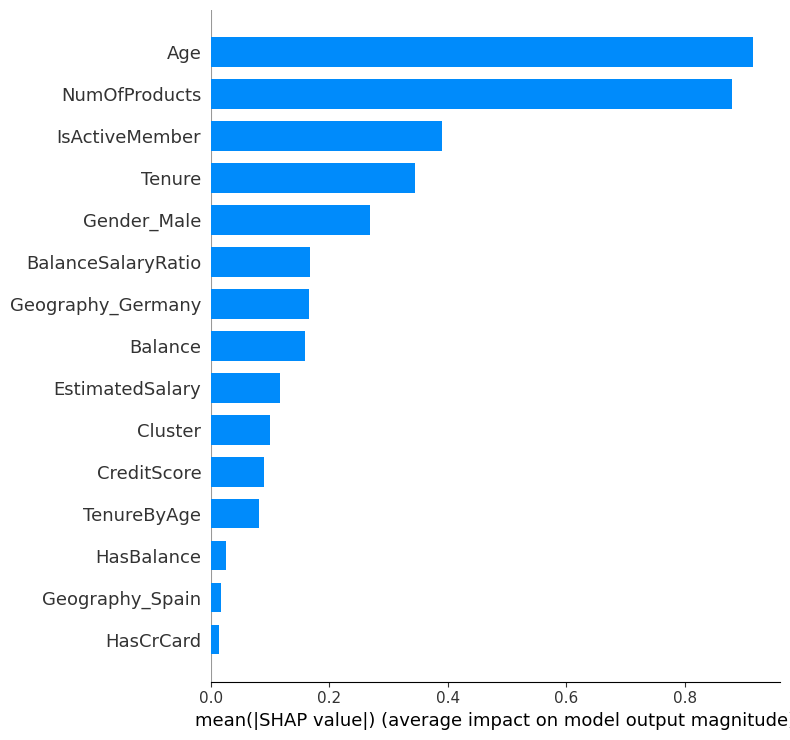

In [ ]:
shap.summary_plot(shap_values, sample, plot_type="bar", show=True)
